In [1]:
#IMPORTING LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#SETTING CHARTS TO HAVE PROFESSIONAL ASTHETICS
sns.set_theme(style="whitegrid")



In [3]:
#LOADING THE DATA
df = pd.read_csv('AB_NYC_2019.csv')

#VIEWING FIRST 5 ROWS
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
#CHECKING DATA TYPES AND MISSING VALUES
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [7]:
#CHECKING NUMBER OF ROWS AND COLUMNA
df.shape

(48895, 16)

In [8]:
#LET'S SEE THE NUMERICAL COLUMNS
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [10]:
#CHECKING MISSING VALUES
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [14]:
#HANDLING MISSING VALUES IN NAME AND HOST_NAME
df['name'] = df['name'].fillna('No name provided')
df['host_name'] = df['host_name'].fillna('Unknown Host')

In [17]:
##HANDLING MISSING VALUES IN LAST REVIEWS AND REVIEWS PER MONTH
# 1 MEANS "HAS REVIEWS", 0 MEANS "NEVER REVIEWED"
df['has_reviews'] = df['last_review'].notnull().astype(int)

In [19]:
#HANDLING MISSING VALUES IN REVIEWS PER MONTH
#I WILL FILL WITH ZERO BECAUSE MISSING VALUES HERE MEANS NO REVIEW WAS CARRIED OUT

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [20]:
#CHECKING TO SEE IF MY DATA HAS BEEN CLEANED SUCCESSFULLY
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
has_reviews                       0
dtype: int64

VISUALIZATION

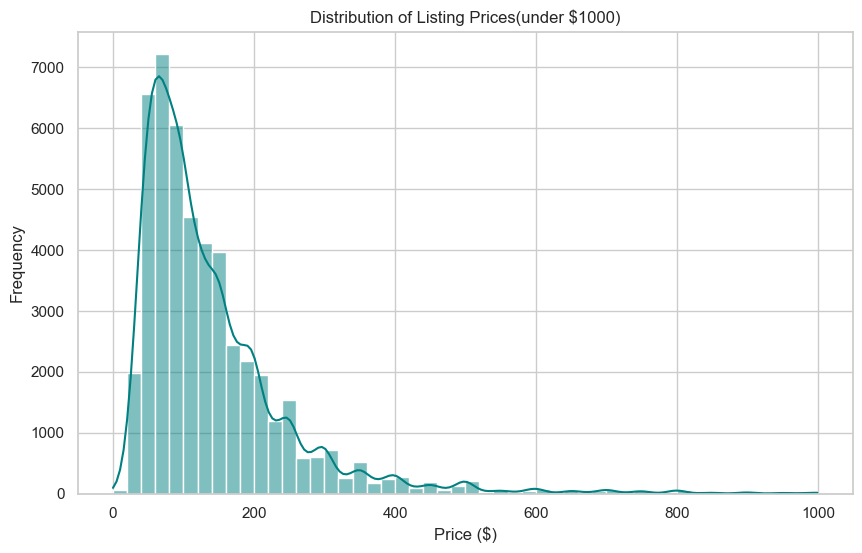

In [27]:
#PRICE ANALYSIS AND DISTRIBUTIONS

#FIGURE SIZE
plt.figure(figsize=(10, 6))

#CREATING A HISTOGRAM PLOT AND GIVING IT WHAT TO PLOT FROM MY DATA
sns.histplot(df[df['price'] < 1000]['price'], bins=50, kde=True, color='teal')

#TITLING THE HISTOGRAM AND NAMING AXES
plt.title('Distribution of Listing Prices(under $1000)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')

#SHOWING PLOT
plt.show()

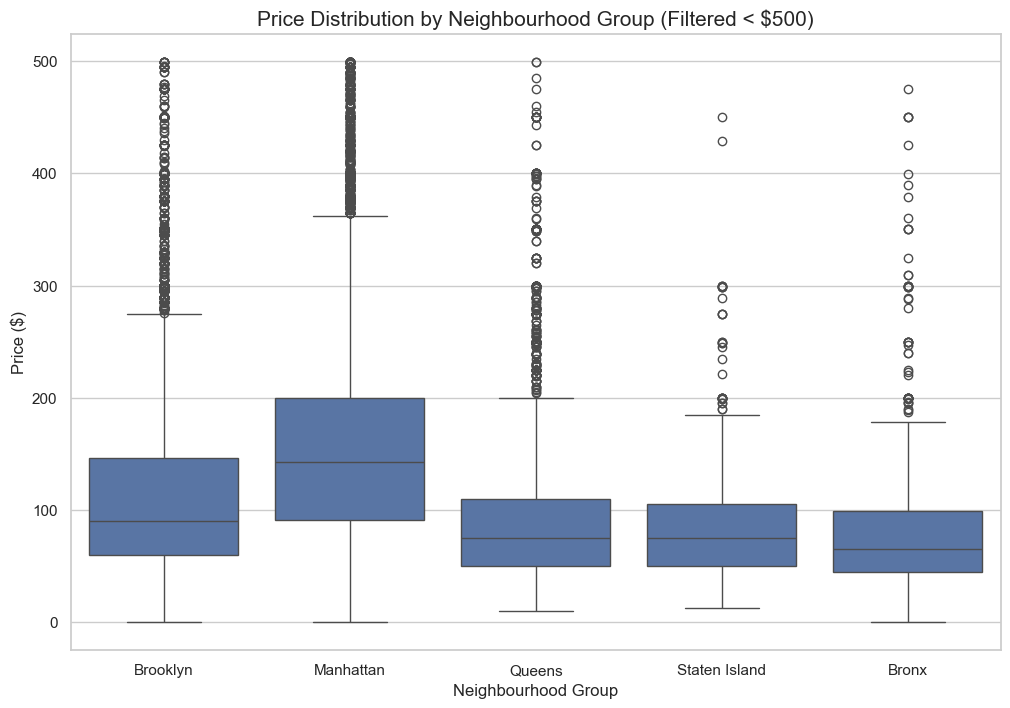

In [29]:
#PRICE AND NEIGHBOURHOOD COMPARISON
plt.figure(figsize=(12, 8))

#CREATING A BOX PLOT GIVING IT WHAT TO PLOT FROM MY DATA
sns.boxplot(x='neighbourhood_group', y='price', data=df[df['price'] < 500])

#GIVING TITLE AND LABELLING AXES
plt.title('Price Distribution by Neighbourhood Group (Filtered < $500)', fontsize=15)
plt.xlabel('Neighbourhood Group', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)

#SHOWING THE PLOT
plt.show()

C:\Users\NEW\AppData\Local\Temp\ipykernel_27700\3182553344.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='room_type', y='availability_365', data=df, palette='viridis', ci=None)
C:\Users\NEW\AppData\Local\Temp\ipykernel_27700\3182553344.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='room_type', y='availability_365', data=df, palette='viridis', ci=None)


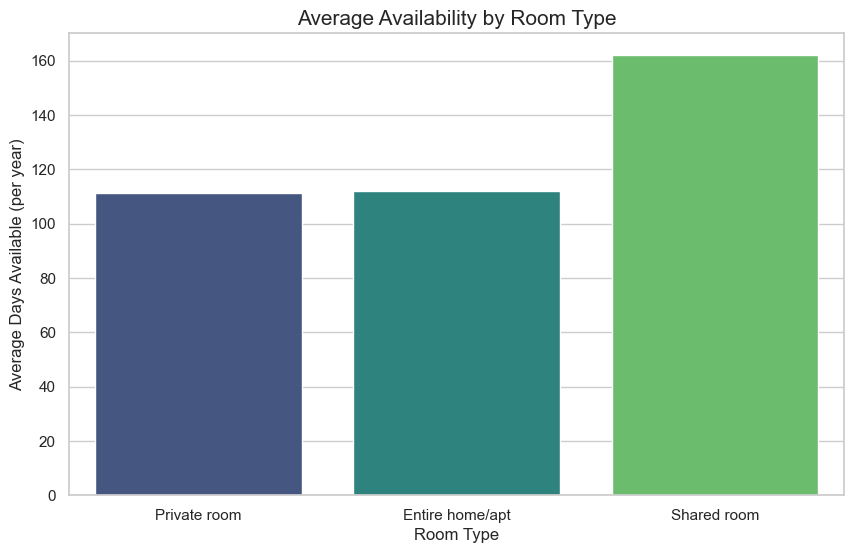

In [31]:
#VISUALIZE ROOM TYPE AND AVAILABILITY WHICH HELPS A CUSTOMER KNOW HOW THE ROOM TYPE AFFECTS AVAILABILTY
plt.figure(figsize=(10, 6))

#CREATIN A BAR GRAPH THIS TIME 
sns.barplot(x='room_type', y='availability_365', data=df, palette='viridis', ci=None)

#TITLING AND LABELLING AXES
plt.title('Average Availability by Room Type', fontsize=15)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Average Days Available (per year)', fontsize=12)

#SHOWING THE GRAPH
plt.show()